In [1]:
# CSS style setting
!wget http://bit.ly/3ZLyF82 -O CSS.css -q

In [2]:
from IPython.core.display import HTML
with open("C:/Users/user/CSS.css", 'r') as file:
    custom_css = file.read()

HTML(custom_css)

In [3]:
import os 
import itertools
import shutil
from PIL import Image
# Data Handling libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix , classification_report , ConfusionMatrixDisplay
# DeepLearning Tools
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Conv2D , MaxPooling2D , Activation , Flatten , BatchNormalization , Dropout
from tensorflow.keras.optimizers import Adam , Adamax
from tensorflow.keras import regularizers

import warnings
warnings.filterwarnings('ignore')

In [28]:
dataset = "C:/Users/user/CNN/file/Rices_Image_Dataset/"
filepaths = []
labels = []
folds= os.listdir(dataset)

for fold in folds:
    f_path = os.path.join(dataset , fold)
    
    if not os.path.isdir(f_path): # if not a directory, skip
        continue
    imgs = os.listdir(f_path)
    
    for img in imgs:
        img_path = os.path.join(f_path , img)
        filepaths.append(img_path)
        labels.append(fold)
        
files = pd.Series(filepaths , name= 'filepaths')
labels = pd.Series(labels ,name = 'labels' )
df = pd.concat([Files , labels] , axis = 1)

In [17]:
df.head()

,filepaths,labels
0,C:/Users/user/CNN/file/Rices_Image_Dataset/Arb...,Arborios
1,C:/Users/user/CNN/file/Rices_Image_Dataset/Arb...,Arborios
2,C:/Users/user/CNN/file/Rices_Image_Dataset/Arb...,Arborios
3,C:/Users/user/CNN/file/Rices_Image_Dataset/Arb...,Arborios
4,C:/Users/user/CNN/file/Rices_Image_Dataset/Arb...,Arborios


In [18]:
class_names = df['labels'].unique().tolist()
class_names

['Arborios', 'basmatis', 'Ipsalas', 'Jasmines', 'Karacadags']

In [26]:
type(class_names)

list

In [29]:
train, dummy = train_test_split(df, train_size = 0.7, random_state = 42, shuffle = True)
valid, test = train_test_split(dummy, train_size = 0.5, random_state = 42, shuffle = True)

In [30]:
print(f"The train data length : {train.shape}")
print(f"The valid data length : {valid.shape}")
print(f"The test data length : {test.shape}")

The train data length : (3500, 2)
The valid data length : (750, 2)
The test data length : (750, 2)


In [37]:
img_size = (150,150)
channels = 3
num_batchs = 16

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()

train_gen = tr_gen.flow_from_dataframe(train, x_col='filepaths', y_col='labels', target_size=img_size, 
                                       class_mode='categorical', color_mode='rgb', shuffle=True, 
                                       batch_size=num_batchs)
valid_gen = ts_gen.flow_from_dataframe(valid, x_col='filepaths', y_col='labels', target_size=img_size, 
                                       class_mode='categorical', color_mode='rgb', shuffle=True, 
                                       batch_size=num_batchs)
test_gen = ts_gen.flow_from_dataframe(test, x_col='filepaths', y_col='labels', target_size=img_size, 
                                       class_mode='categorical', color_mode='rgb', shuffle=False, 
                                       batch_size=num_batchs)

Found 3500 validated image filenames belonging to 5 classes.
Found 750 validated image filenames belonging to 5 classes.
Found 750 validated image filenames belonging to 5 classes.


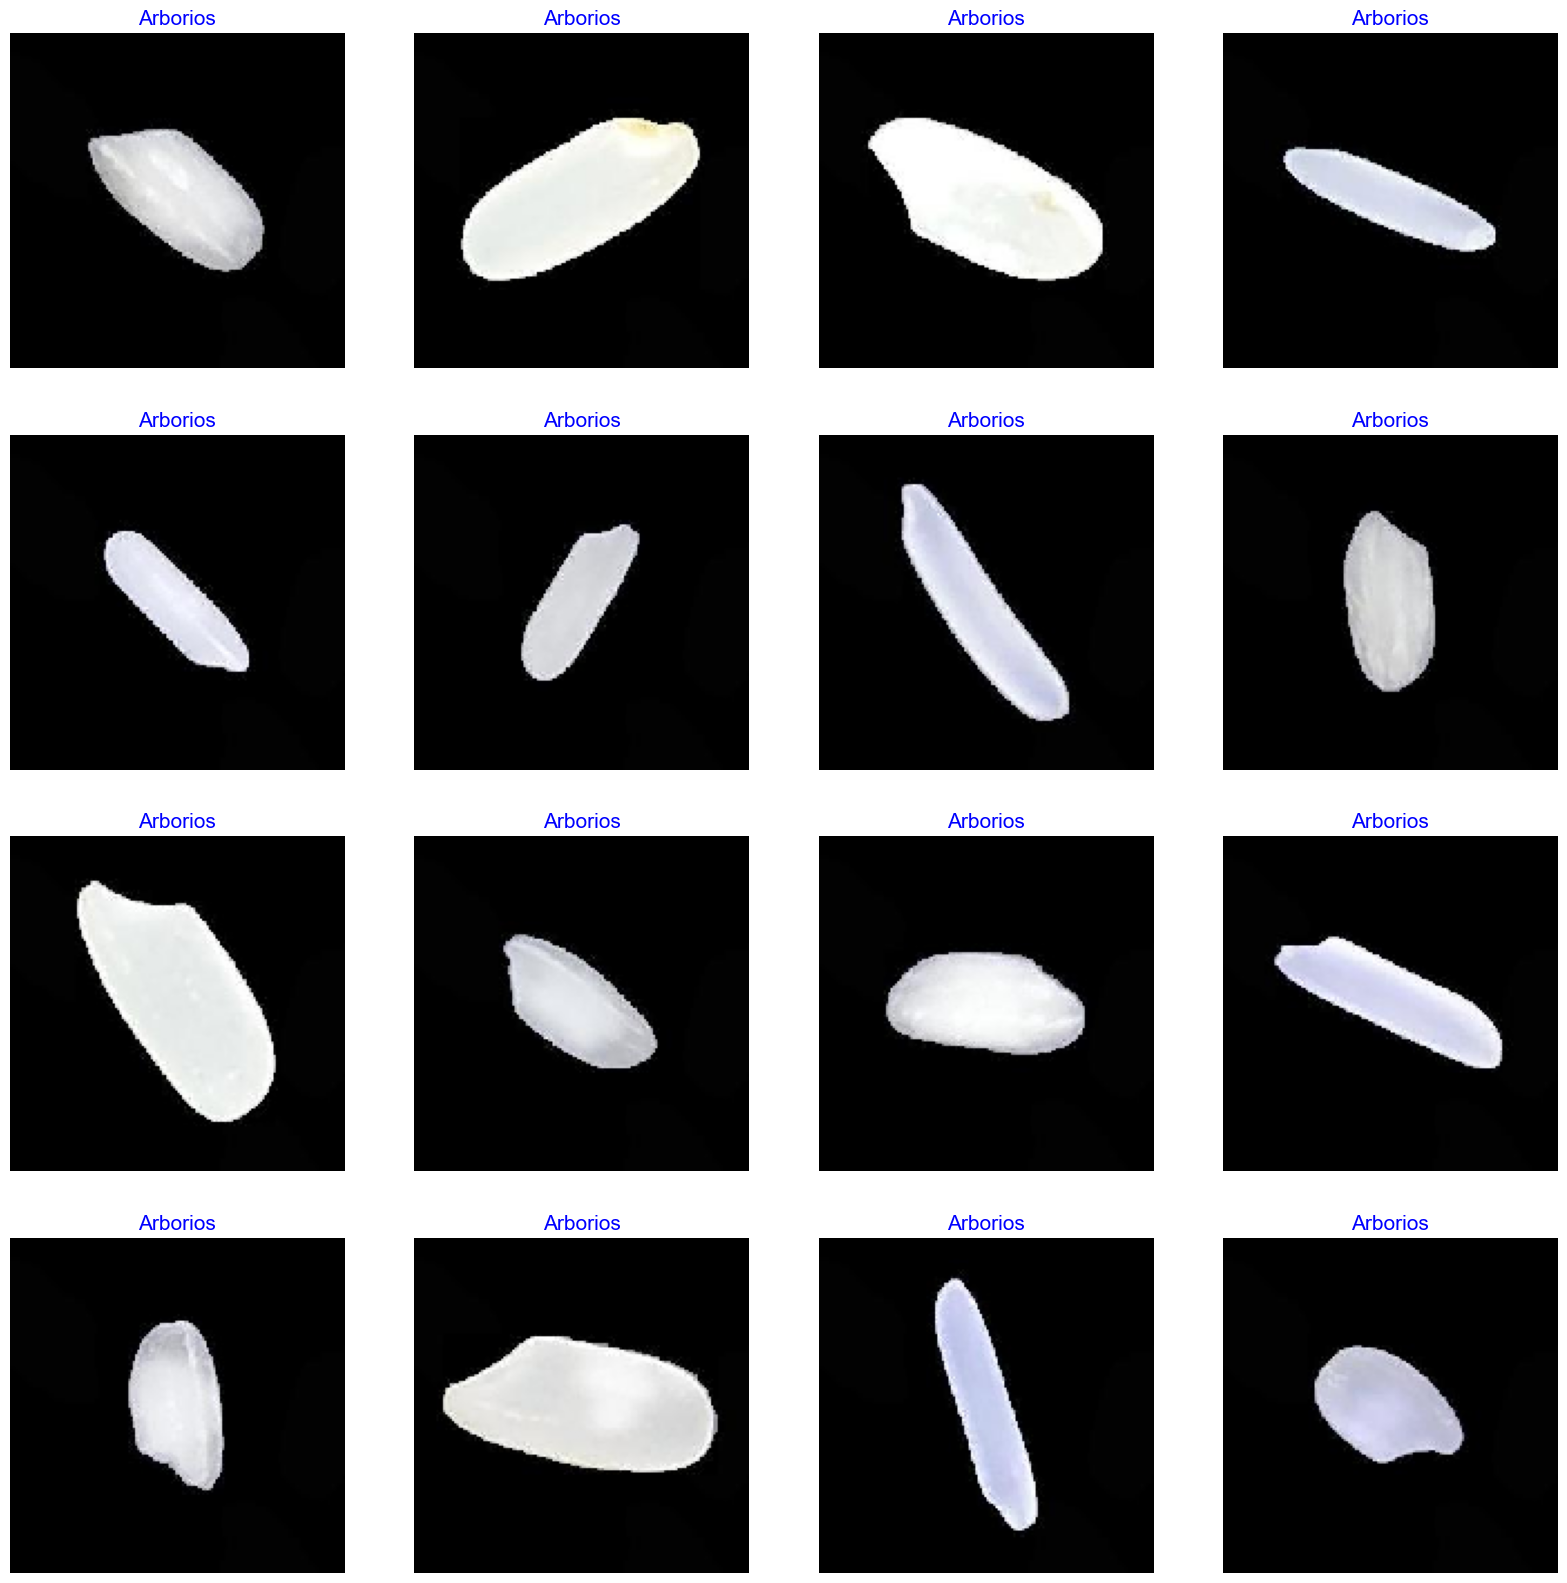

In [41]:
dict_gen = test_gen.class_indices
classes = list(dict_gen.keys())
images, label = next(test_gen)

plt.figure(figsize=(20,20))
for i in range(16):
    plt.subplot(4,4,i+1)
    image = images[i] / 255
    plt.imshow(image)
    index = np.argmax(labels[i])
    plt.title(classes[index], color = 'blue', fontsize = 15)
    plt.axis('off')
plt.show()

In [43]:
img_shape = (img_size[0], img_size[1], channels)
class_count = len(classes)
base_model = tf.keras.applications.efficientnet.EfficientNetB7(include_top = False,
                                                               weights = 'imagenet',
                                                               input_shape = img_shape,
                                                               pooling = 'max')
base_model.trainable = False

model = Sequential([
    base_model,
    BatchNormalization(axis = -1, momentum = 0.99, epsilon = 0.001),
    Dense(256, activation = 'relu'),
    Dropout(rate = 0.2, seed = 123),
    Dense(class_count, activation = 'softmax')
])
model.compile(Adamax(learning_rate = 0.001), loss = 'categorical_crossentropy', metrics = ['accuracy'])
model.summary()



258076736/258076736 [==============================] - 12s 0us/step
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb7 (Functional  (None, 2560)              64097687  
 )                                                               
                                                                 
 batch_normalization (Batch  (None, 2560)              10240     
 Normalization)                                                  
                                                                 
 dense (Dense)               (None, 256)               655616    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 5)                 1285      
                                                    

In [45]:
checkpoint_path = ".cp/ckpt"
cp_callback = tf.keras.callbacks.ModelCheckpoint(filepath = checkpoint_path,
                                                 save_weights_only = True,
                                                 verbose = 1)
num_epochs = 10
history = model.fit(x=train_gen, validation_data = valid_gen, epochs = num_epochs, verbose = 1,
                    validation_steps = None, shuffle = False, callbacks = [cp_callback])

Epoch 1/10


219/219 [==============================] - ETA: 0s - loss: 0.2502 - accuracy: 0.9223
Epoch 1: saving model to .cp\ckpt
219/219 [==============================] - 196s 800ms/step - loss: 0.2502 - accuracy: 0.9223 - val_loss: 0.0480 - val_accuracy: 0.9853
Epoch 2/10
219/219 [==============================] - ETA: 0s - loss: 0.1252 - accuracy: 0.9580
Epoch 2: saving model to .cp\ckpt
219/219 [==============================] - 167s 764ms/step - loss: 0.1252 - accuracy: 0.9580 - val_loss: 0.0314 - val_accuracy: 0.9880
Epoch 3/10
219/219 [==============================] - ETA: 0s - loss: 0.0908 - accuracy: 0.9703
Epoch 3: saving model to .cp\ckpt
219/219 [==============================] - 168s 766ms/step - loss: 0.0908 - accuracy: 0.9703 - val_loss: 0.0324 - val_accuracy: 0.9880
Epoch 4/10
219/219 [==============================] - ETA: 0s - loss: 0.0980 - accuracy: 0.9691
Epoch 4: saving model to .cp\ckpt
219/219 [==============================] - 167s 762ms/step - loss: 0.0980

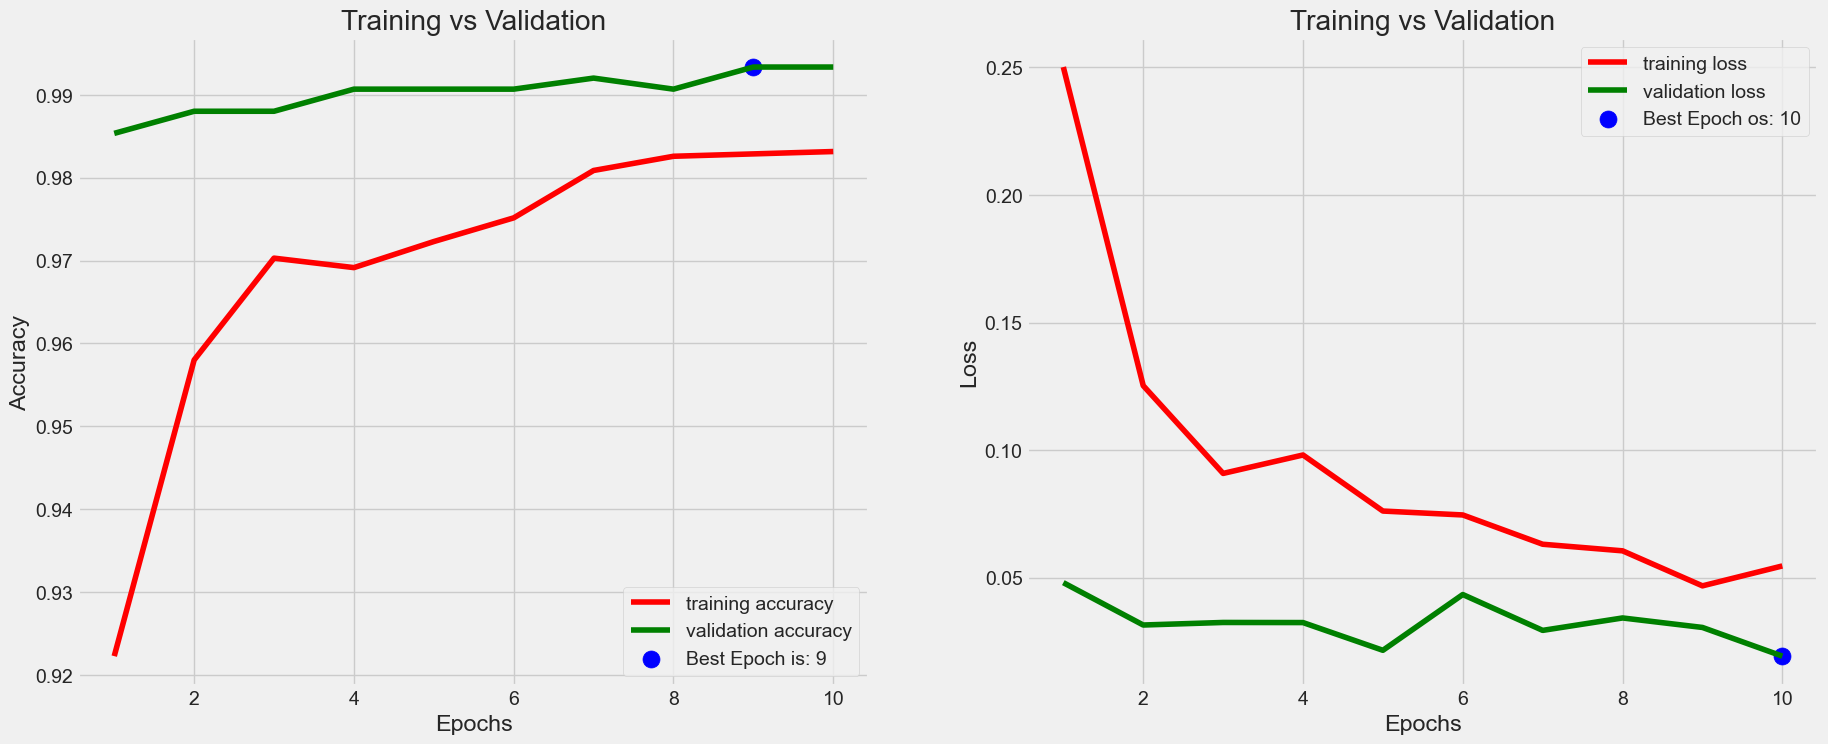

In [49]:
train_acc = history.history['accuracy']
train_loss = history.history['loss']

val_acc = history.history['val_accuracy']
val_loss = history.history['val_loss']

index_loss = np.argmin(val_loss)
index_acc = np.argmax(val_acc)

val_lowest = val_loss[index_loss]
val_highest = val_acc[index_acc]

epochs = [i+1 for i in range(len(train_acc))]
acc_label = f"Best Epoch is: {str(index_acc + 1)}"
loss_label = f"Best Epoch os: {str(index_loss + 1)}"

plt.figure(figsize=(20,8))
plt.style.use('fivethirtyeight')

plt.subplot(1,2,1)
plt.plot(epochs, train_acc, 'r', label = 'training accuracy')
plt.plot(epochs, val_acc, 'g', label = 'validation accuracy')
plt.scatter(index_acc + 1, val_highest, s=150, c = 'blue', label = acc_label)
plt.title("Training vs Validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_loss, 'r', label = 'training loss')
plt.plot(epochs, val_loss, 'g', label = 'validation loss')
plt.scatter(index_loss + 1, val_lowest, s=150, c = 'blue', label = loss_label)
plt.title("Training vs Validation")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout
plt.show()

In [50]:
train_score = model.evaluate(train_gen, steps = 64, verbose = 1)
test_score = model.evaluate(test_gen, steps = 64, verbose = 1)
val_score = model.evaluate(valid_gen, steps = 64, verbose = 1)

64/64 [==============================] - 29s 446ms/step - loss: 0.0192 - accuracy: 0.9933


In [52]:
print("Train Loss:", train_score[0])
print("Train Accuracy:", train_score[1])
print("-" * 20)
print("validation Loss:", val_score[0])
print("validation Accuracy:", val_score[1])
print("-" * 20)
print("test Loss:", test_score[0])
print("test Accuracy:", test_score[1])

Train Loss: 0.006940435618162155
Train Accuracy: 0.9970703125
--------------------
validation Loss: 0.019167978316545486
validation Accuracy: 0.9933333396911621
--------------------
test Loss: 0.03411239758133888
test Accuracy: 0.9919999837875366


In [53]:
preds = model.predict_generator(test_gen)
y_pred = np.argmax(preds, axis = 1)

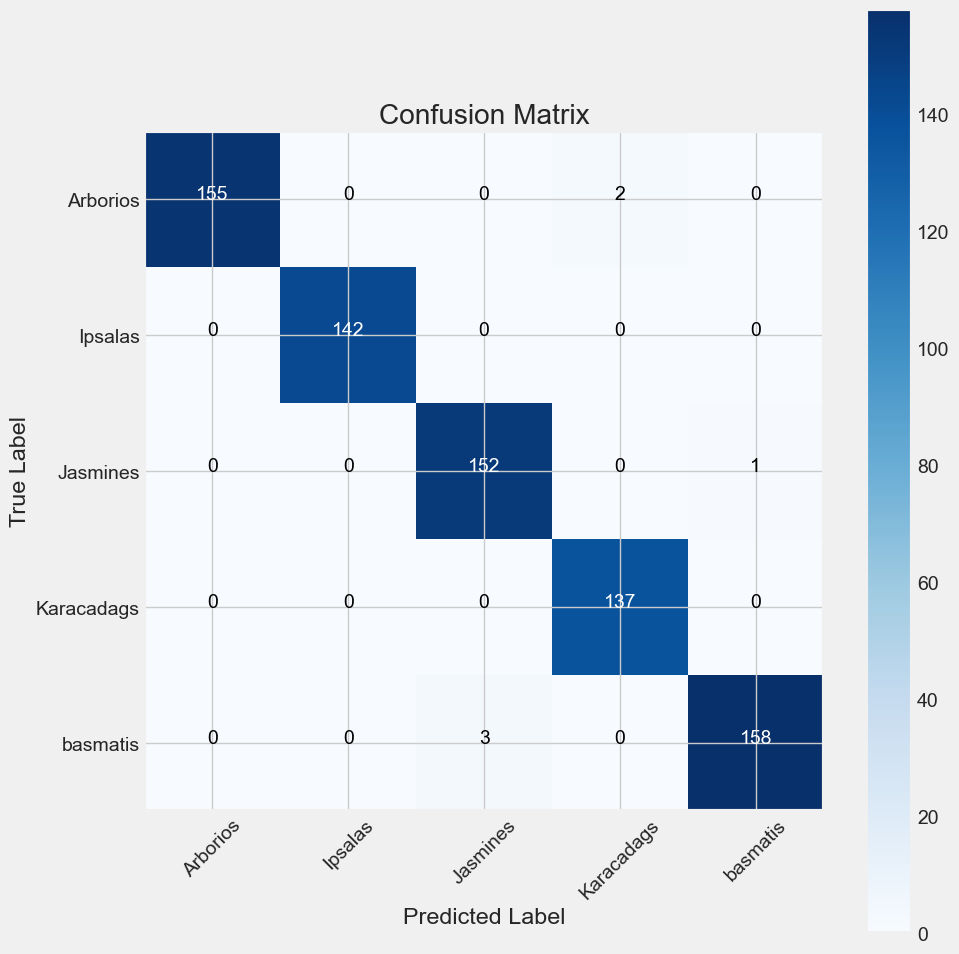

In [54]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)


thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [55]:
print(classification_report(test_gen.classes, y_pred , target_names= classes ))

              precision    recall  f1-score   support

    Arborios       1.00      0.99      0.99       157
     Ipsalas       1.00      1.00      1.00       142
    Jasmines       0.98      0.99      0.99       153
  Karacadags       0.99      1.00      0.99       137
    basmatis       0.99      0.98      0.99       161

    accuracy                           0.99       750
   macro avg       0.99      0.99      0.99       750
weighted avg       0.99      0.99      0.99       750

